# uber project

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
uber_df=pd.read_csv(r"C:\Users\ELCOT\Downloads\uberdrive.csv")
#uber_df[:-1]
#uber_df.shape
#uber_df.info()
#uber_df.size
uber_df.columns # display all columns
#uber_df.columns[0] 
#list(uber_df.columns) # display columns in list
#uber_df.dtypes # display the data type of the columns 
#uber_df.select_dtypes(include=['float']) # to select particular datatype 



Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')

# data preprocessing

In [12]:
uber_df['PURPOSE*'].fillna('not',inplace=True)
uber_df.isnull().sum()

START_DATE*    0
END_DATE*      1
CATEGORY*      1
START*         1
STOP*          1
MILES*         0
PURPOSE*       0
dtype: int64

In [13]:
#uber_df.columns.str.strip()
uber_df.columns.str.lower()
#uber_df.columns.str.replace('*','')
uber_df.columns

Index(['START_DATE*', 'END_DATE*', 'CATEGORY*', 'START*', 'STOP*', 'MILES*',
       'PURPOSE*'],
      dtype='object')

In [14]:
uber_df.columns=uber_df.columns.str.lower()
uber_df.columns
uber_df.columns=uber_df.columns.str.replace('*','',regex=False)
uber_df.columns

Index(['start_date', 'end_date', 'category', 'start', 'stop', 'miles',
       'purpose'],
      dtype='object')

# chech duplicate

In [15]:
#uber_df.duplicated() # gives boolean value
#uber_df[uber_df.duplicated()] # gives the duplicated rows
#uber_df.drop_duplicates(inplace=True) # to remove the duplpicate 
uber_df.describe() # for numerical 
#uber_df.describe(include=['object']) # for categorical value 
uber_df.describe(include=['object','number']) # to diplay both 

,start_date,end_date,category,start,stop,miles,purpose
count,1156,1155,1155,1155,1155,1156.000000,1156
unique,1155,1154,2,177,188,NaN,11
top,6/28/2016 23:34,6/28/2016 23:59,Business,Cary,Cary,NaN,not
freq,2,2,1078,201,203,NaN,503
mean,NaN,NaN,NaN,NaN,NaN,21.115398,NaN
std,NaN,NaN,NaN,NaN,NaN,359.299007,NaN
min,NaN,NaN,NaN,NaN,NaN,0.500000,NaN
25%,NaN,NaN,NaN,NaN,NaN,2.900000,NaN
50%,NaN,NaN,NaN,NaN,NaN,6.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,10.400000,NaN


# converting datatype one to another

In [16]:
uber_df['start_date']=pd.to_datetime(uber_df['start_date'],errors='coerce')
uber_df['end_date']=pd.to_datetime(uber_df['end_date'],errors='coerce')


In [17]:
uber_df.describe()

,start_date,end_date,miles
count,421,420,1156.000000
mean,2016-07-01 12:31:09.976247040,2016-07-01 12:11:10.142857216,21.115398
min,2016-01-01 21:11:00,2016-01-01 21:17:00,0.500000
25%,2016-04-01 13:43:00,2016-03-27 15:10:00,2.900000
50%,2016-07-04 18:23:00,2016-07-04 18:19:00,6.000000
75%,2016-10-10 17:22:00,2016-10-10 17:39:15,10.400000
max,2016-12-12 20:48:00,2016-12-12 20:57:00,12204.700000
std,NaN,NaN,359.299007


# to get only the date and only time

In [18]:
from datetime import datetime 
uber_df['date']=pd.DatetimeIndex(uber_df['start_date']).date
uber_df['time']=pd.DatetimeIndex(uber_df['start_date']).hour

In [19]:
uber_df

,start_date,end_date,category,start,stop,miles,purpose,date,time
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1.0
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0
...,...,...,...,...,...,...,...,...,...
1151,NaT,NaT,Business,Kar?chi,Unknown Location,3.9,Temporary Site,NaT,NaN
1152,NaT,NaT,Business,Unknown Location,Unknown Location,16.2,Meeting,NaT,NaN
1153,NaT,NaT,Business,Katunayake,Gampaha,6.4,Temporary Site,NaT,NaN
1154,NaT,NaT,Business,Gampaha,Ilukwatta,48.2,Temporary Site,NaT,NaN


# splitting the time

In [20]:
uber_df['day-night']=pd.cut(x=uber_df['time'],bins=[0,10,15,19,24],labels=['morning','afternoon','evening','night'])

In [21]:
uber_df.head()

,start_date,end_date,category,start,stop,miles,purpose,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21.0,night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,not,2016-01-02,1.0,morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20.0,night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17.0,evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14.0,afternoon


# data visualization

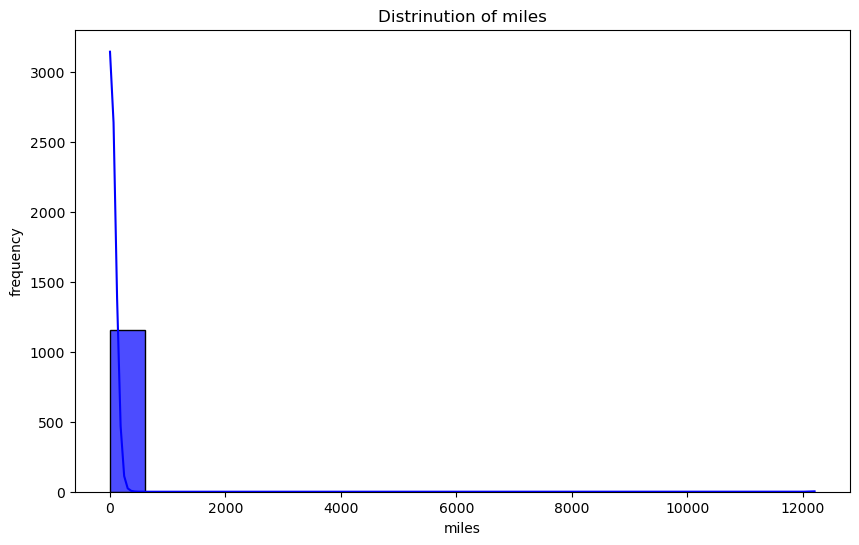

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(uber_df['miles'],bins=20,kde=True,color='blue',edgecolor='black',alpha=0.7)
plt.xlabel('miles')
plt.ylabel('frequency')
plt.title('Distrinution of miles')
plt.show()

In [23]:
print(uber_df['start'].unique()) 
print(uber_df['start'].nunique())
print(uber_df['stop'].unique()) 
print(uber_df['stop'].nunique()) 

['Fort Pierce' 'West Palm Beach' 'Cary' 'Jamaica' 'New York' 'Elmhurst'
 'Midtown' 'East Harlem' 'Flatiron District' 'Midtown East'
 'Hudson Square' 'Lower Manhattan' "Hell's Kitchen" 'Downtown' 'Gulfton'
 'Houston' 'Eagan Park' 'Morrisville' 'Durham' 'Farmington Woods'
 'Whitebridge' 'Lake Wellingborough' 'Fayetteville Street' 'Raleigh'
 'Hazelwood' 'Fairmont' 'Meredith Townes' 'Apex' 'Chapel Hill'
 'Northwoods' 'Edgehill Farms' 'Tanglewood' 'Preston' 'Eastgate'
 'East Elmhurst' 'Jackson Heights' 'Long Island City' 'Katunayaka'
 'Unknown Location' 'Colombo' 'Nugegoda' 'Islamabad' 'R?walpindi'
 'Noorpur Shahan' 'Heritage Pines' 'Westpark Place' 'Waverly Place'
 'Wayne Ridge' 'Weston' 'East Austin' 'West University' 'South Congress'
 'The Drag' 'Congress Ave District' 'Red River District' 'Georgian Acres'
 'North Austin' 'Coxville' 'Convention Center District' 'Austin' 'Katy'
 'Sharpstown' 'Sugar Land' 'Galveston' 'Port Bolivar' 'Washington Avenue'
 'Briar Meadow' 'Latta' 'Jacksonville'

In [24]:
uber_df['start'].value_counts().head(10)

start
Cary                201
Unknown Location    148
Morrisville          85
Whitebridge          68
Islamabad            57
Durham               37
Lahore               36
Raleigh              28
Kar?chi              27
Westpark Place       17
Name: count, dtype: int64

In [25]:
uber_df['start'].value_counts().index[:10]# get first 10 value in start column  

Index(['Cary', 'Unknown Location', 'Morrisville', 'Whitebridge', 'Islamabad',
       'Durham', 'Lahore', 'Raleigh', 'Kar?chi', 'Westpark Place'],
      dtype='object', name='start')

<Axes: xlabel='count', ylabel='start'>

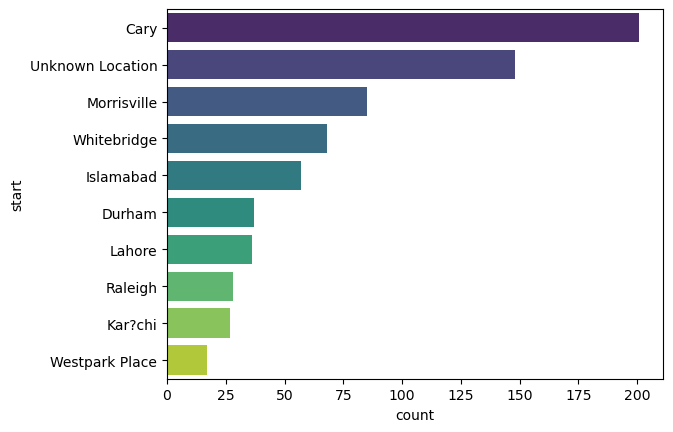

In [26]:
sns.countplot(y='start',
              data=uber_df,
              order=uber_df['start'].value_counts().index[:10],
              #hue='start',
              palette='viridis')

# how to avoid warning

In [27]:
import warnings
warnings.filterwarnings('ignore') # all the warning are ignored 
#warnings.filterwarnings('ignore',
 #                       message='hello',
 #                       lineno=21,
  #                      module='module_name',
   #                     category='category_name') # warning with the word hello will be ignored 


In [28]:
uber_df['category'].unique()

array(['Business', 'Personal', nan], dtype=object)

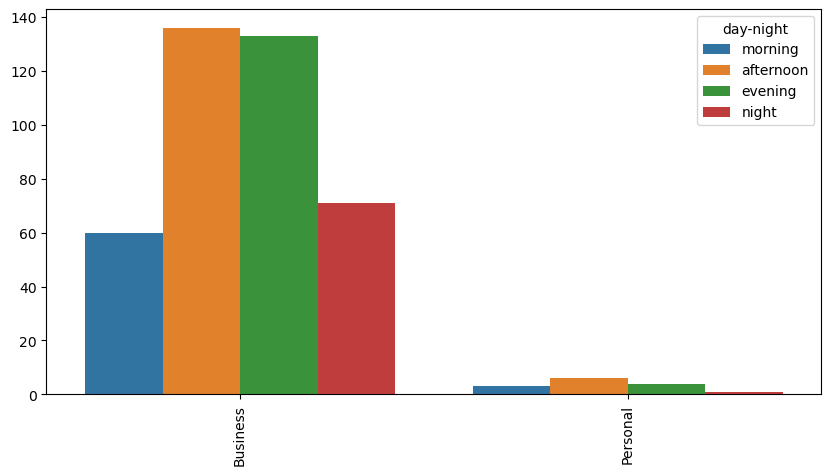

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(data=uber_df,x='category',hue='day-night')#palette='set2')
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('')
plt.show()

# histplot with stack

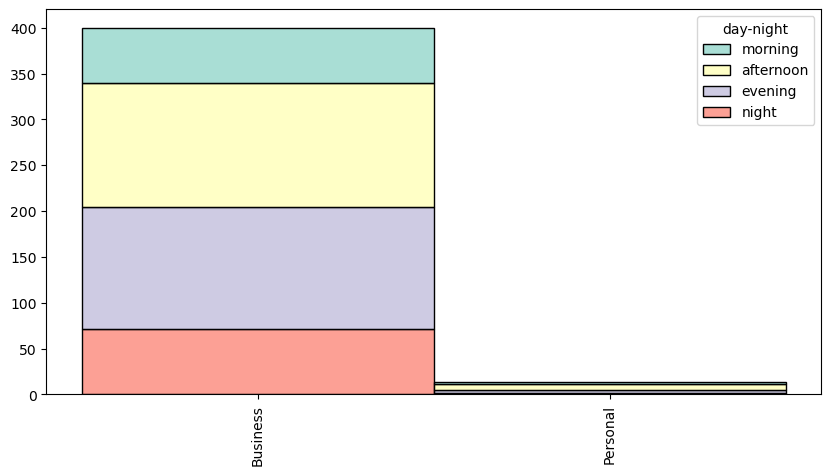

In [30]:
plt.figure(figsize=(10,5))
sns.histplot(data=uber_df,
             x='category',
             multiple='stack',
             hue='day-night',
             palette='Set3')
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('')
plt.show()
# gives the output in histplot and in stacked manner 

# without stack

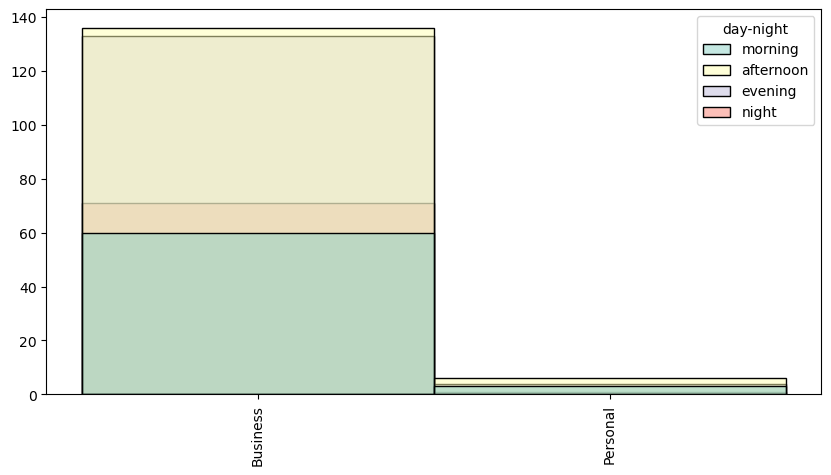

In [31]:
plt.figure(figsize=(10,5))
sns.histplot(data=uber_df,
             x='category',
            
             hue='day-night',
             palette='Set3')
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('')
plt.show()

# for normalizing and proposition

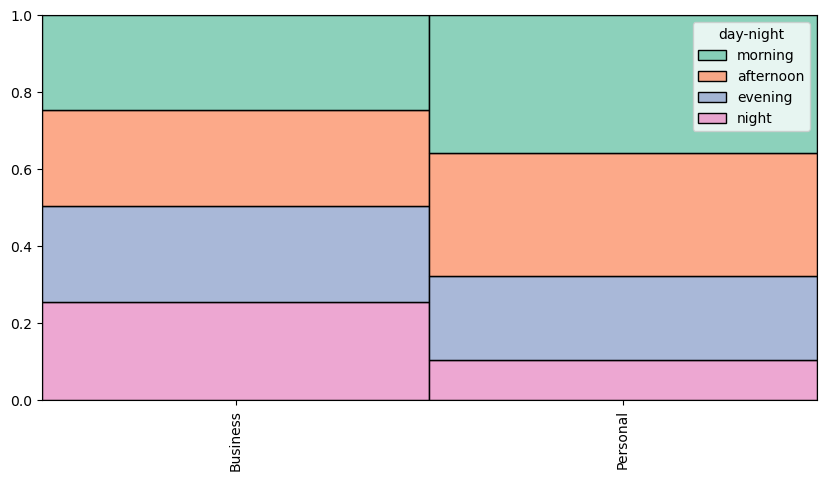

In [32]:
plt.figure(figsize=(10,5))
sns.histplot(data=uber_df,x='category',
             multiple='fill',
             stat='probability',
             common_norm=False, # normalize each category wise if normalize=True it will normalize whole category 
             hue='day-night',
             palette='Set2')
plt.xticks(rotation=90)
plt.xlabel('')
plt.ylabel('')
plt.show()


# heatmap

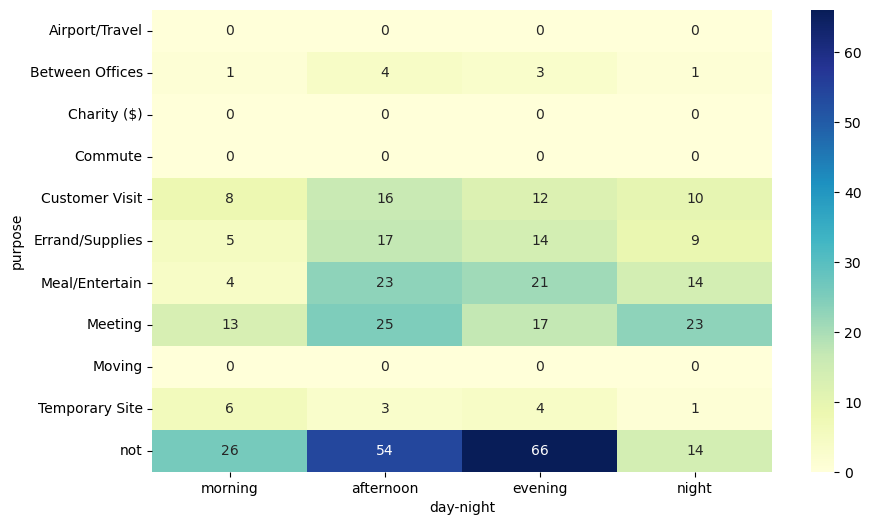

In [33]:
plt.figure(figsize=(10,6))
heat_map=(uber_df.groupby(['purpose','day-night'])).size().unstack() #or
#heat_map=pd.crosstab(uber_df['purpose'],uber_df['day-night'],normalize='index')# normalize is used to convert the count into percentage 
sns.heatmap(heat_map,annot=True,cmap='YlGnBu',fmt='d')# annot is used to diaplay the value and fmt is used to convert into integer
plt.show()


# pie chart

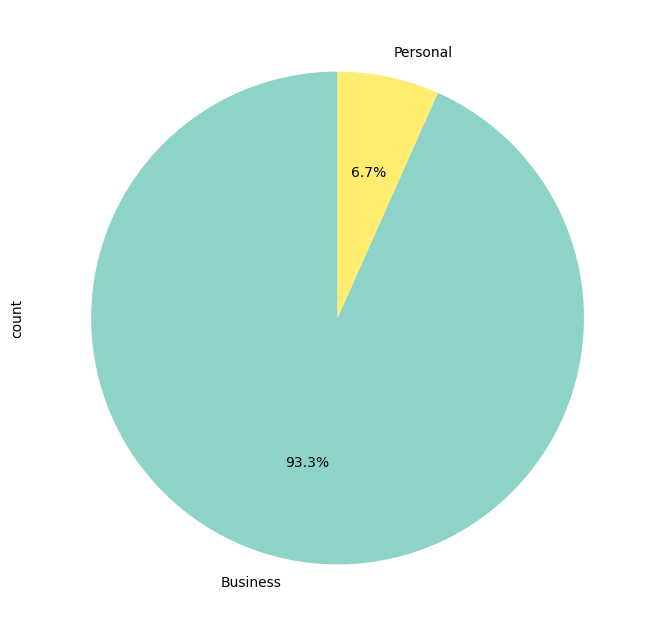

In [34]:
plt.figure(figsize=(8,8))
uber_df['category'].value_counts().plot.pie(startangle=90,
                                            cmap='Set3',
                                            autopct='%1.1f%%')
#plt.ylabel('')
plt.show()

# pie chart using erxplode

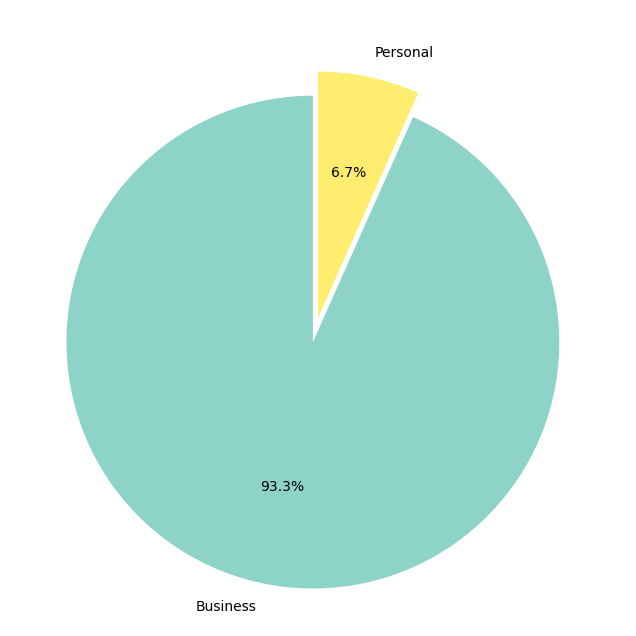

In [35]:
plt.figure(figsize=(8,8))
explode=[0.1 if cat.lower()=='business' else 0 
         for cat in uber_df['category'].value_counts().index]
uber_df['category'].value_counts().plot.pie(startangle=90,cmap='Set3',autopct='%.1f%%',explode=explode)
plt.ylabel('')
plt.show()

# pie chart using legends

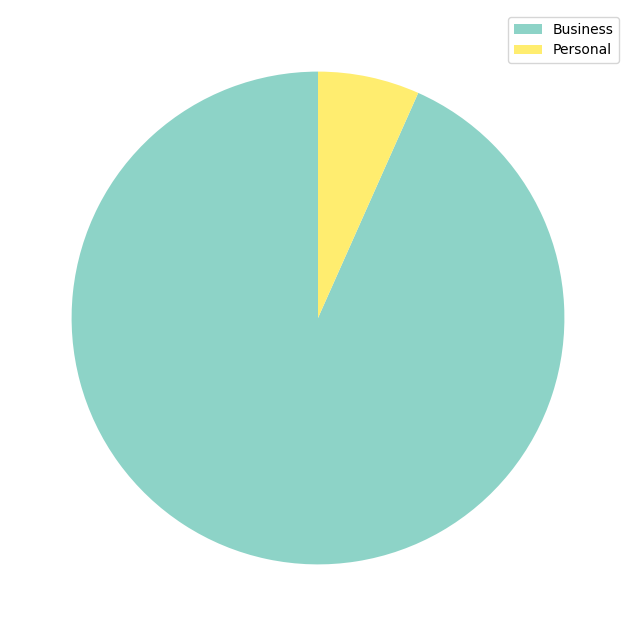

In [45]:
plt.figure(figsize=(8,8))
uber_df['category'].value_counts().plot.pie(startangle=90,cmap='Set3',autopct=None,labels=None)
plt.legend(labels=uber_df['category'].value_counts().index,loc='upper right')
plt.ylabel('')
plt.show()

# pie chart to display both percentage and value

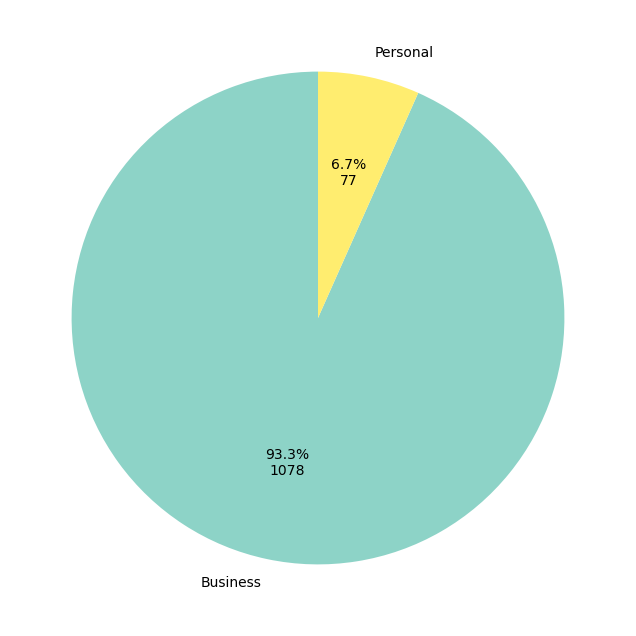

In [26]:
plt.figure(figsize=(8,8))
def auto_value(pct,value):
    total=sum(value)
    absolute=int(pct/100.*total)
    return (f'{pct:.1f}%\n{absolute}')
uber_df['category'].value_counts().plot.pie(startangle=90,cmap='Set3',autopct=lambda pct : auto_value(pct,uber_df['category'].value_counts()))

plt.ylabel('')
plt.show()

# box plot

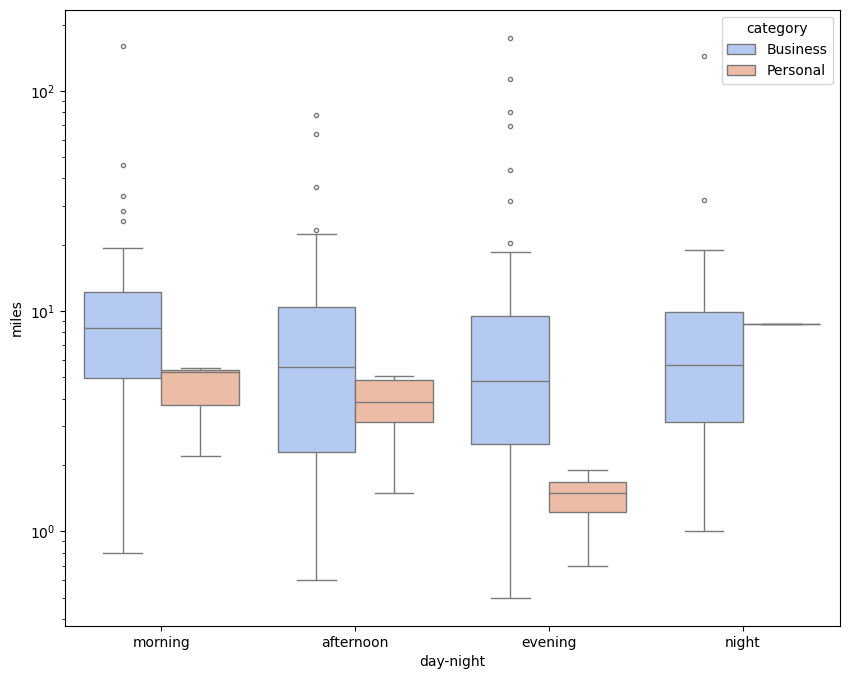

In [27]:
plt.figure(figsize=(10,8))
sns.boxplot(data=uber_df,x='day-night',
            y='miles',
            hue='category',
            palette='coolwarm',
            showfliers=True,
            fliersize=3)# showfiler is used to show the outlier and the size is used to make the outlier size bigger
plt.yscale('log') # for clear view
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

# swramplot

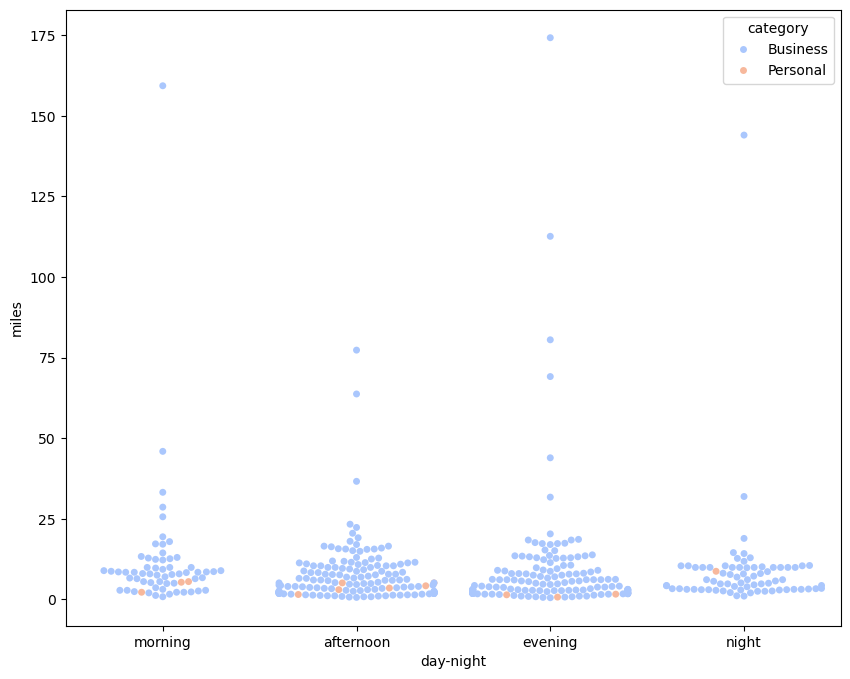

In [46]:
plt.figure(figsize=(10,8))
sns.swarmplot(data=uber_df,x='day-night',y='miles',hue='category',palette='coolwarm')
#sns.boxplot(data=uber_df,x='day-night',y='miles',size=3,color='black')
plt.xlabel('day-night')
plt.ylabel('miles')
plt.show()

# facegrid

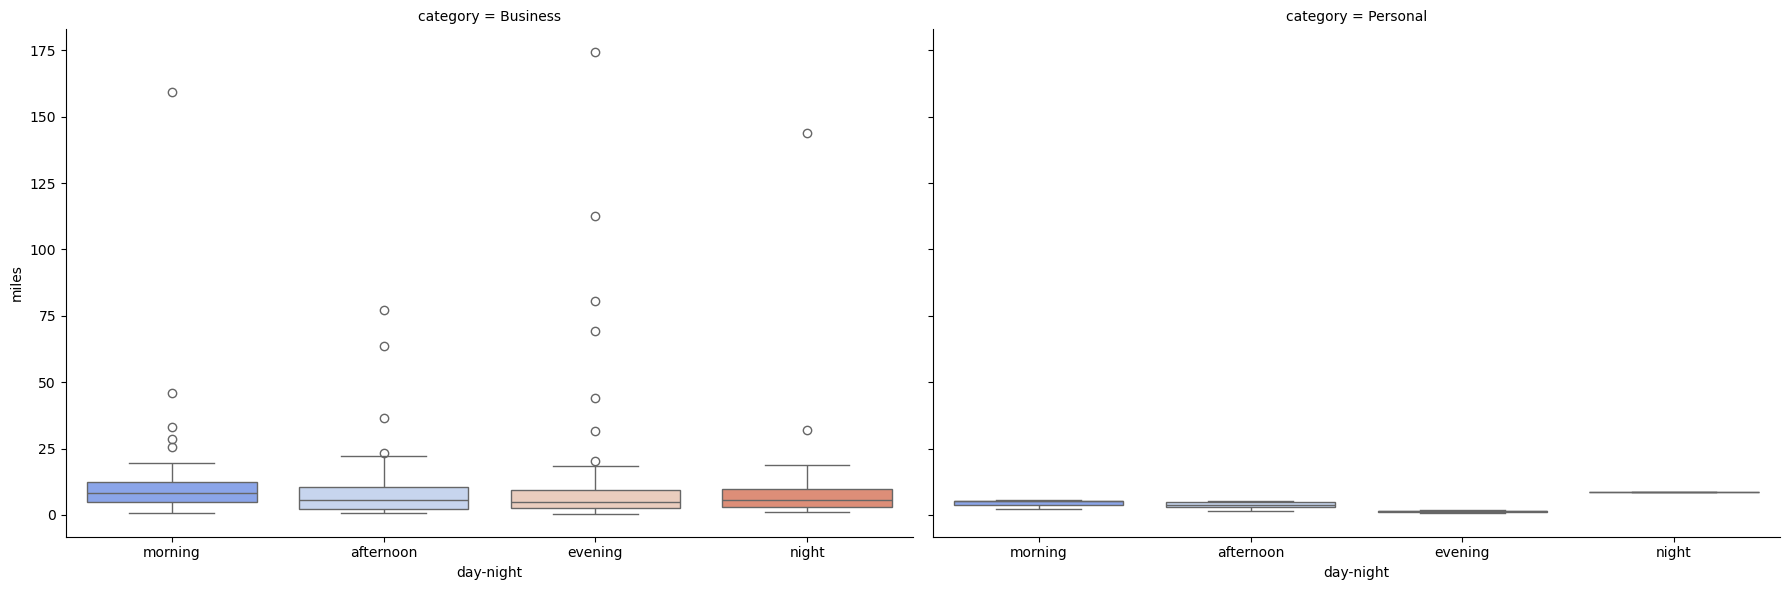

In [48]:
g=sns.FacetGrid(uber_df,col='category',height=6,aspect=1.5)# if we use aspect ,aspect=width*height i.e 6*1.5
g.map(sns.boxplot,'day-night','miles',palette='coolwarm')
#g.set_axis_label('day-night','miles')
#g.suptitle('')
plt.show()

# violin plot

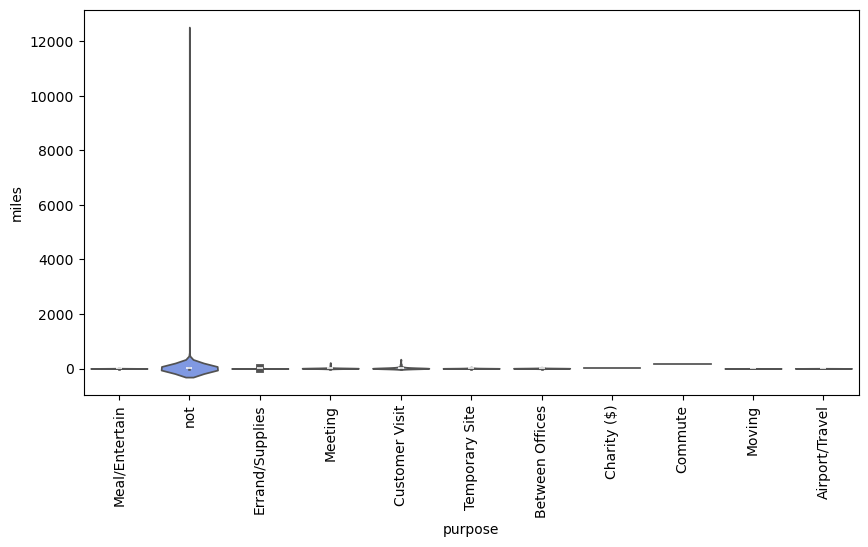

In [49]:
plt.figure(figsize=(10,5))
sns.violinplot(data=uber_df,x='purpose',y='miles',palette='coolwarm')
plt.xticks(rotation=90)
plt.show()

# using whitegrid for background change

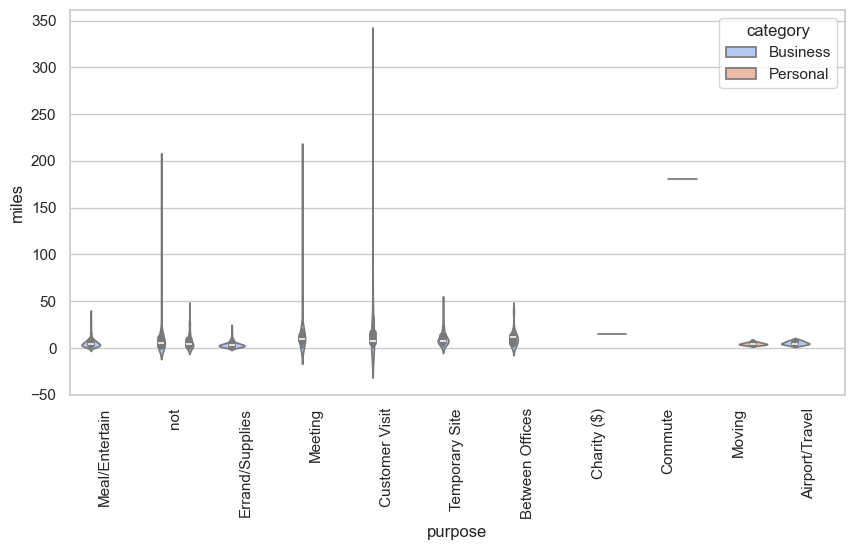

In [50]:
sns.set(style='whitegrid') # background will be white 
plt.figure(figsize=(10,5))
sns.violinplot(data=uber_df,x='purpose',y='miles',hue='category',palette='coolwarm')
plt.xticks(rotation=90)
plt.show()

# box plot inside violin plot

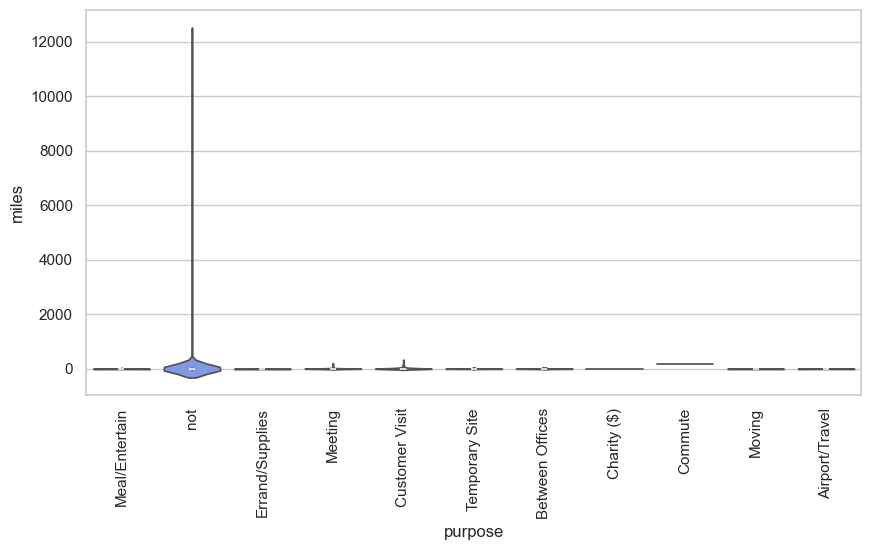

In [51]:
sns.set(style='whitegrid') # background will be white 
plt.figure(figsize=(10,5))
sns.violinplot(data=uber_df,x='purpose',y='miles',inner='box',scale='width',palette='coolwarm')
plt.xticks(rotation=90)
plt.show()

# bar plot

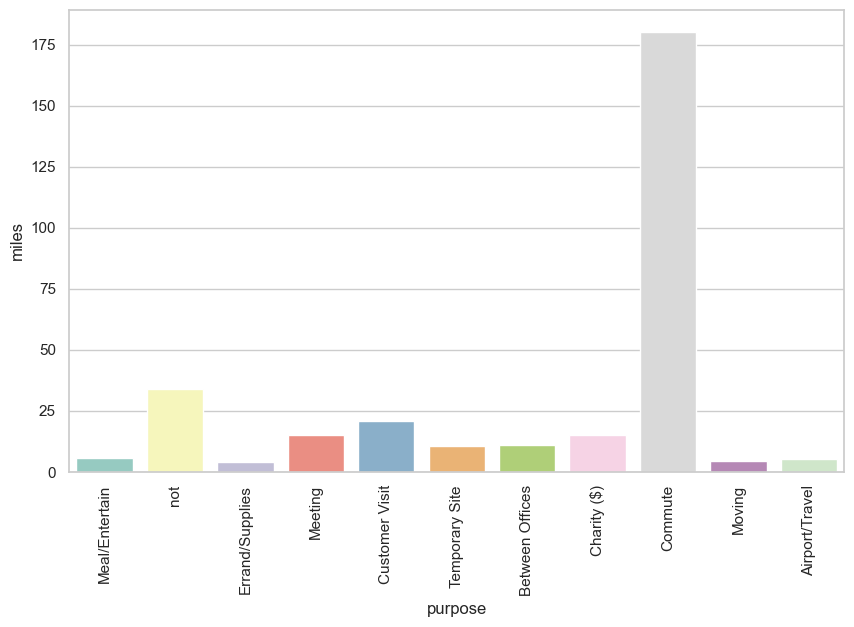

In [52]:
plt.figure(figsize=(10,6))
sns.barplot(data=uber_df,
            x='purpose',
            y='miles',
            estimator=np.mean,
            ci=None,
            hue='purpose',
            palette='Set3',
           legend=False)
plt.xticks(rotation=90)
plt.show()


# sorting in barplot

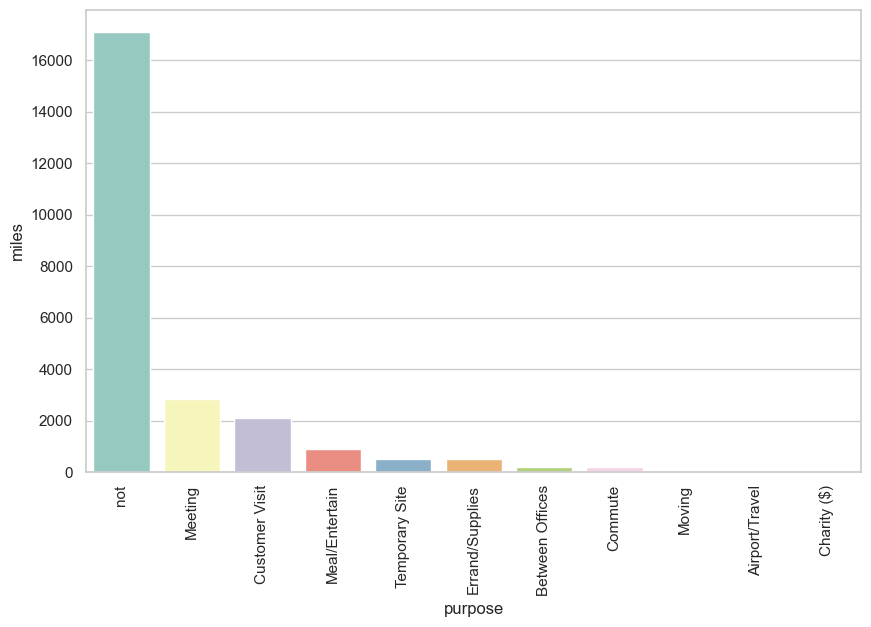

In [53]:
plt.figure(figsize=(10,6))
order=uber_df.groupby('purpose')['miles'].sum().sort_values(ascending=False).index
sns.barplot(data=uber_df,
            x='purpose',
            y='miles',
            estimator=np.sum,
            ci=None,
            order=order,
            palette='Set3')
plt.xticks(rotation=90)
plt.show()

# annotation function

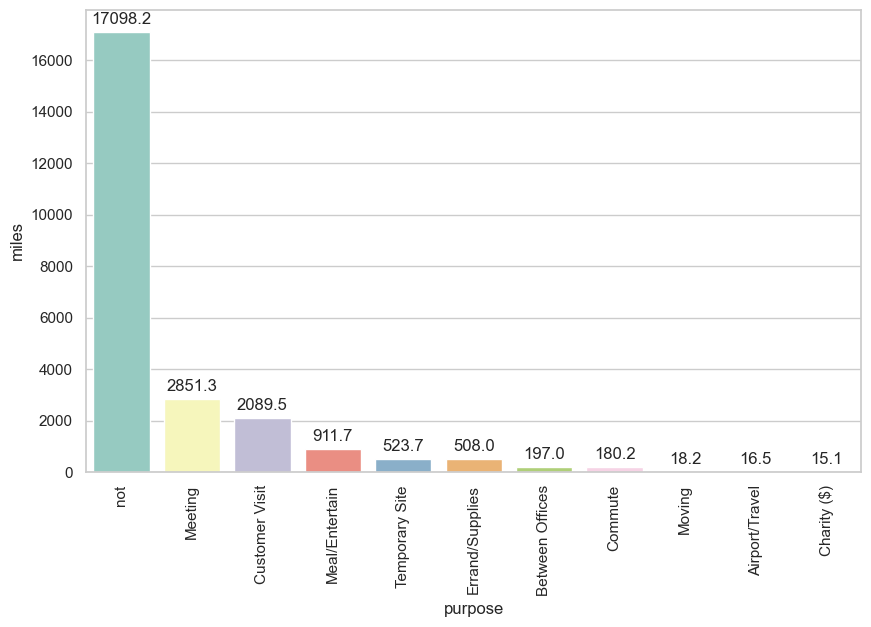

In [54]:
plt.figure(figsize=(10,6))
order=uber_df.groupby('purpose')['miles'].sum().sort_values(ascending=False).index
ax=sns.barplot(data=uber_df,
               x='purpose',
               y='miles',
               estimator=np.sum,
               order=order,
               ci=None,
               palette='Set3')
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha='center',
        va='center',
        xytext=(0,9),
        textcoords='offset points')
plt.xticks(rotation=90)
plt.show()

# scatterplot

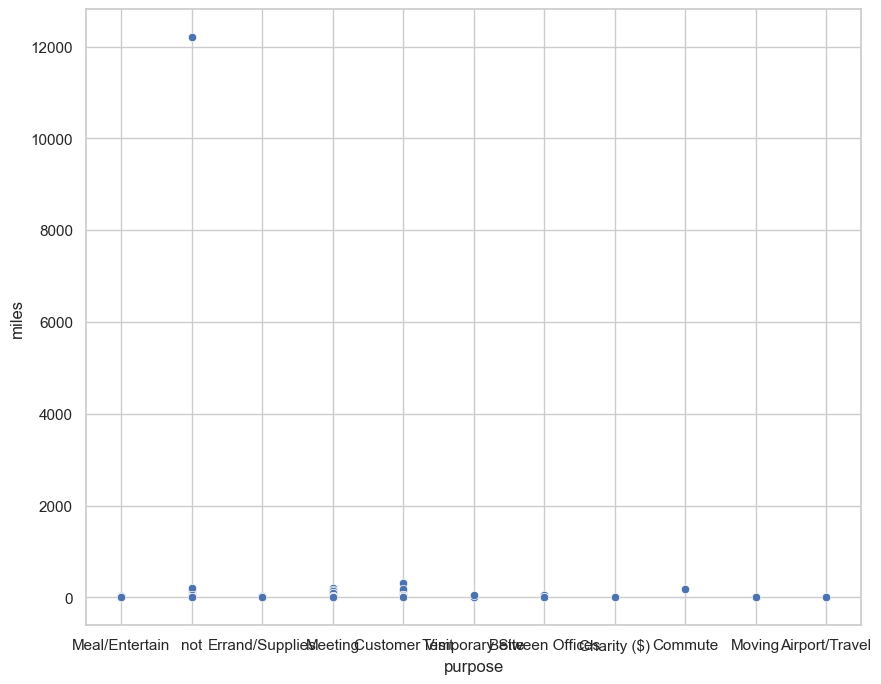

In [55]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=uber_df,y='miles',x='purpose')
plt.show()

# regplot

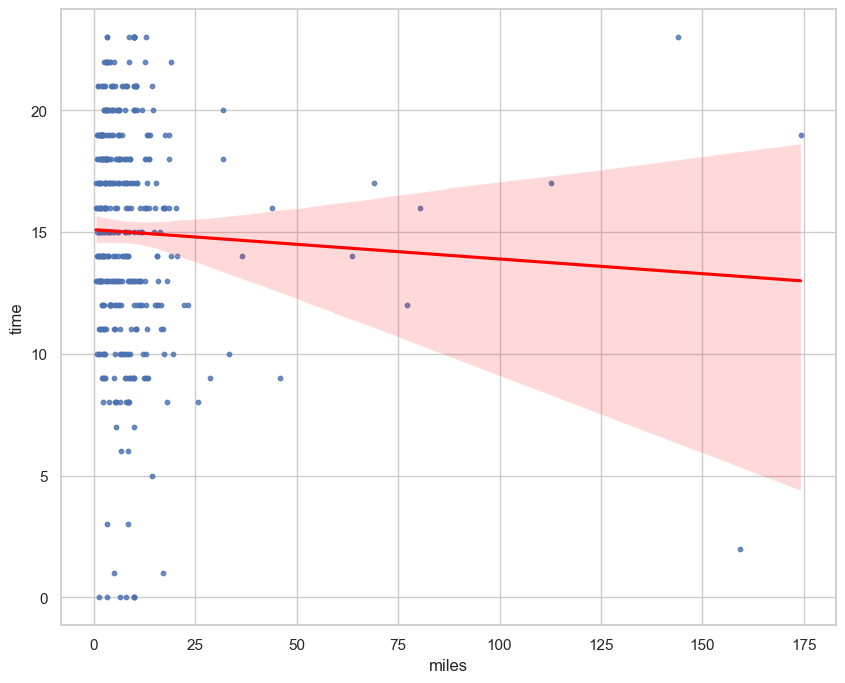

In [65]:
plt.figure(figsize=(10,8))
sns.regplot(data=uber_df,x='miles',y='time',scatter_kws={'s':10},line_kws={'color':'red'})
plt.show()

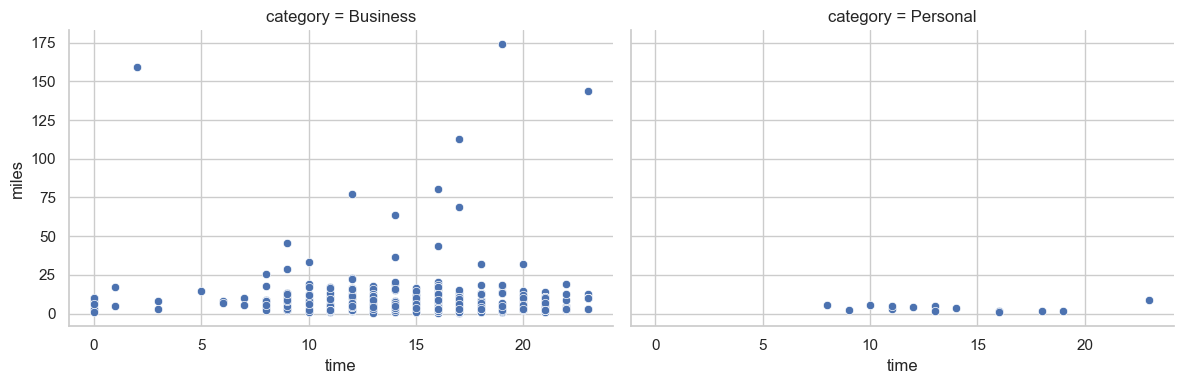

In [59]:
g=sns.FacetGrid(uber_df,col='category',height=4,aspect=1.5)
g.map(sns.scatterplot,'time','miles')
plt.show()

# stripplot

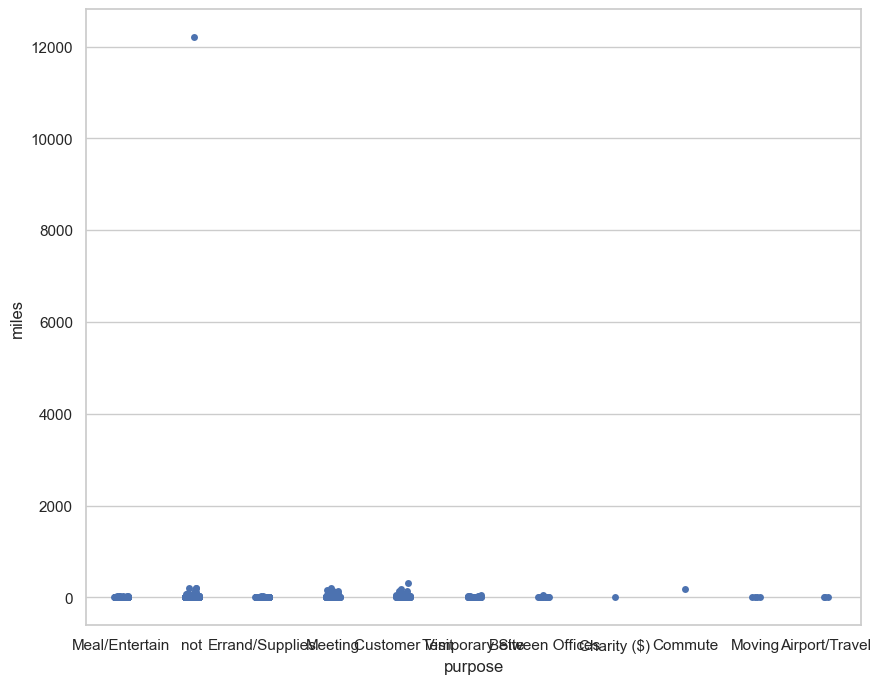

In [60]:
plt.figure(figsize=(10,8))
sns.stripplot(data=uber_df,y='miles',x='purpose',jitter=True)
plt.show()

In [66]:
uber_df['round']=np.where(uber_df['start']==uber_df['stop'],'yes','no')

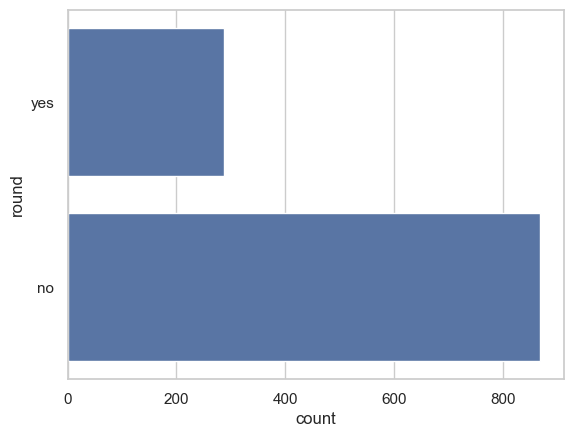

In [67]:
#def round(row):
 #   if row['start']==row['stop']:
  #      return 'yes'
  #  else:
 #       return 'no'
#uber_df['round']=uber_df.apply(round_trip,axis=1)
sns.countplot(uber_df['round'])
plt.show()

In [69]:
uber_df['month']=pd.DatetimeIndex(uber_df['start_date']).month
uber_df['month']

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
1151    NaN
1152    NaN
1153    NaN
1154    NaN
1155    NaN
Name: month, Length: 1156, dtype: float64

In [70]:
dict={1:'jan',2:'feb',3:'mar',4:'apr'}
uber_df['month'].map(dict)

0       jan
1       jan
2       jan
3       jan
4       jan
       ... 
1151    NaN
1152    NaN
1153    NaN
1154    NaN
1155    NaN
Name: month, Length: 1156, dtype: object

# minute calculation lineplot

<Axes: xlabel='minutes', ylabel='miles'>

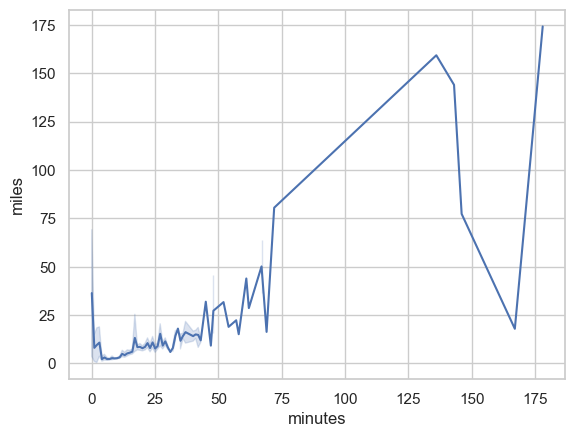

In [105]:
uber_df['minutes']=(uber_df['end_date']-uber_df['start_date']).dt.total_seconds()/60
sns.lineplot(data=uber_df,
             x='minutes',
             y='miles') #dt.total_seconds()/60 converts seconds into mminute 

In [85]:
pd.DataFrame({'min':uber_df.groupby(['purpose'])['miles'].min(),
              'mean':uber_df.groupby(['purpose'])['miles'].mean(),
              'max':uber_df.groupby(['purpose'])['miles'].max()})

,min,mean,max
purpose,,,
Airport/Travel,4.1,5.500000,7.6
Between Offices,1.9,10.944444,39.2
Charity ($),15.1,15.100000,15.1
Commute,180.2,180.200000,180.2
Customer Visit,0.8,20.688119,310.3
Errand/Supplies,0.5,3.968750,22.3
Meal/Entertain,0.6,5.698125,36.5
Meeting,0.7,15.247594,201.0
Moving,3.3,4.550000,6.1


In [87]:
pd.set_option('display.max_rows',None) # to display all rows 
pd.set_option('display.max_columns',None)# to display all columns
pd.set_option('display.max_colwidth',200) # to incerase the width size to display all the letter
pd.set_option('display.float_format','{:.2f}'.format) # to add 2 decimal to all the integer
pd.set_option('display.precision',3) # round off 
pd.set_option('display.expand_frame_repr',False)
pd.set_option('display.large_repr','info')
#uber_df.groupby(['month']['purpose'])('round_trip').count()

In [88]:
data={f'column_{i}':list(range(500))for i in range(10)}
pd.DataFrame(data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   column_0  500 non-null    int64
 1   column_1  500 non-null    int64
 2   column_2  500 non-null    int64
 3   column_3  500 non-null    int64
 4   column_4  500 non-null    int64
 5   column_5  500 non-null    int64
 6   column_6  500 non-null    int64
 7   column_7  500 non-null    int64
 8   column_8  500 non-null    int64
 9   column_9  500 non-null    int64
dtypes: int64(10)
memory usage: 39.2 KB

In [89]:
pd.reset_option('display.large_repr')

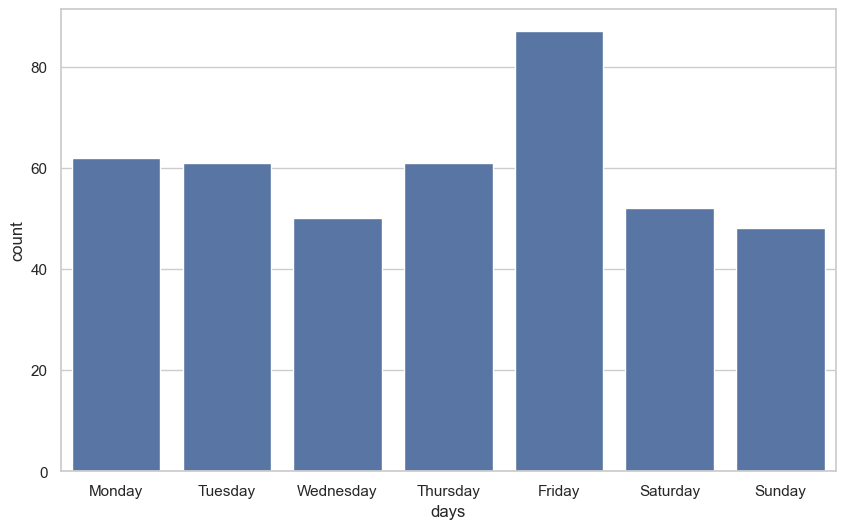

In [96]:
uber_df['days']=uber_df['start_date'].dt.day_name()
plt.figure(figsize=(10,6))
sns.countplot(data=uber_df,x='days',order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.show()

<Axes: ylabel='count'>

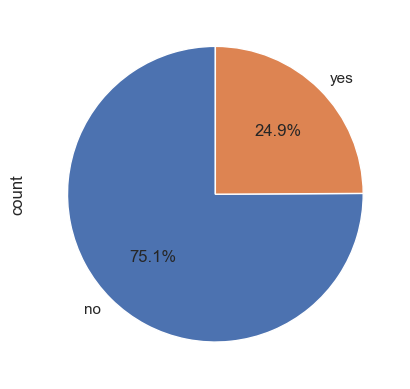

In [100]:
round_trip=uber_df['round'].value_counts()
round_trip.plot.pie(autopct='%1.1f%%',startangle=90,color='coolwarm')

In [101]:
uber_df['top']=uber_df['start'].value_counts().head(10)
ax=sns.countplot(data=uber_df,x='top')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',(p.get_x()+p.get_width()/2.p.get_height(),va='center',ha='center')
                
    
plt.show()


SyntaxError: invalid decimal literal (3581980136.py, line 4)

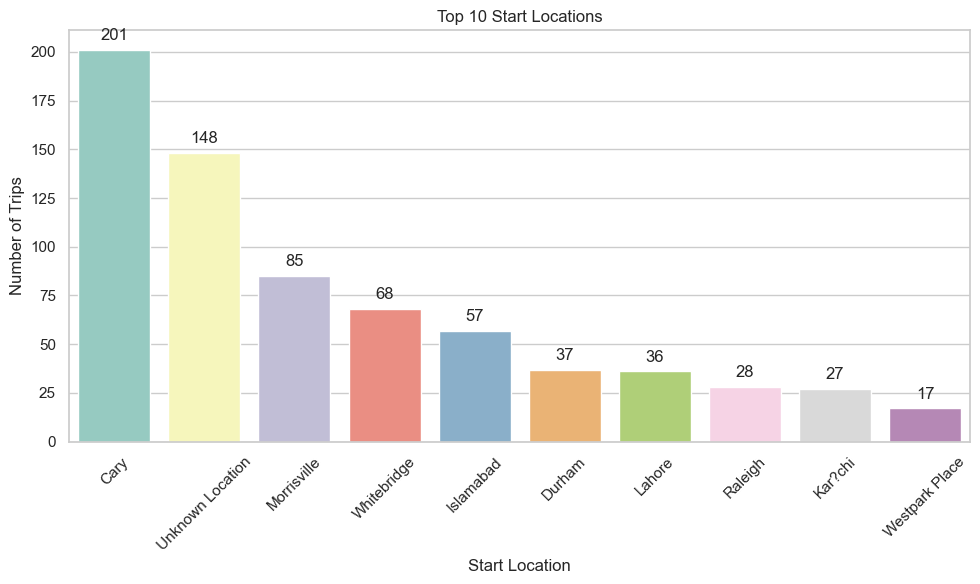

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10 = uber_df['start'].value_counts().head(10)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_10.index,
    y=top_10.values,
    palette='Set3'
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points'
    )

plt.xticks(rotation=45)
plt.xlabel('Start Location')
plt.ylabel('Number of Trips')
plt.title('Top 10 Start Locations')
plt.tight_layout()
plt.show()

<Axes: xlabel='time', ylabel='count'>

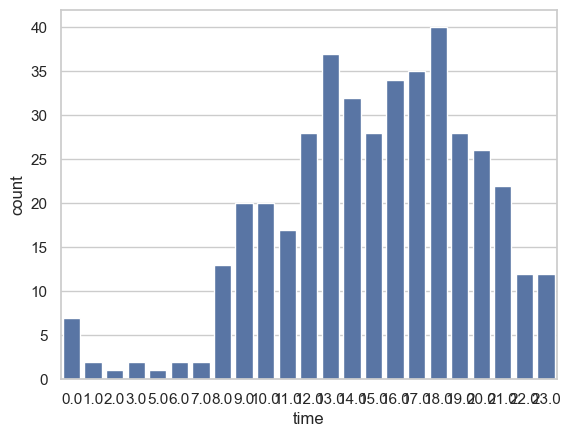

In [84]:
sns.countplot(data=uber_df,x='time')

In [82]:
uber_df.columns.str.replace('*','',regex=False).str.replace(' ','').str.lower().str.strip()

Index(['start_date', 'end_date', 'category', 'start', 'stop', 'miles',
       'purpose', 'date', 'time', 'day-night', 'round', 'month', 'minutes',
       'same_location'],
      dtype='object')

In [ ]:
uber_df['weeekday']=uber_df['start'].dt.day_name()
hello=uber_df.groupby('weekday').size()
avg=hello/uber_df['weekday'].nunique()


In [ ]:
uber_df(uber_df['round']=='yes'.group_by('start').size().sort_values(ascending=False).head(5))

In [80]:
uber_df.groupby('day-night')['miles'].mean()

day-night
morning      11.631746
afternoon     7.729577
evening       9.547445
night         8.850000
Name: miles, dtype: float64

In [78]:
same_location=uber_df[uber_df['start']==uber_df['stop']]
uber_df['same_location']=same_location['miles']
#num_same_location=same_location.shape[0]
average_miles=same_location['miles'].mean()